In [ ]:
# -*- coding: utf-8 -*-
############################################################
# Implementación de una red siamesa de reconocimiento facial
# (Tensorflow)
# Autor: Jaime Duque Domingo
# Libro: Visión Artificial mediante Aprendizaje Automático con
# Tensorflow y Pytorch (2024) Alfaomega Grupo Editor
############################################################


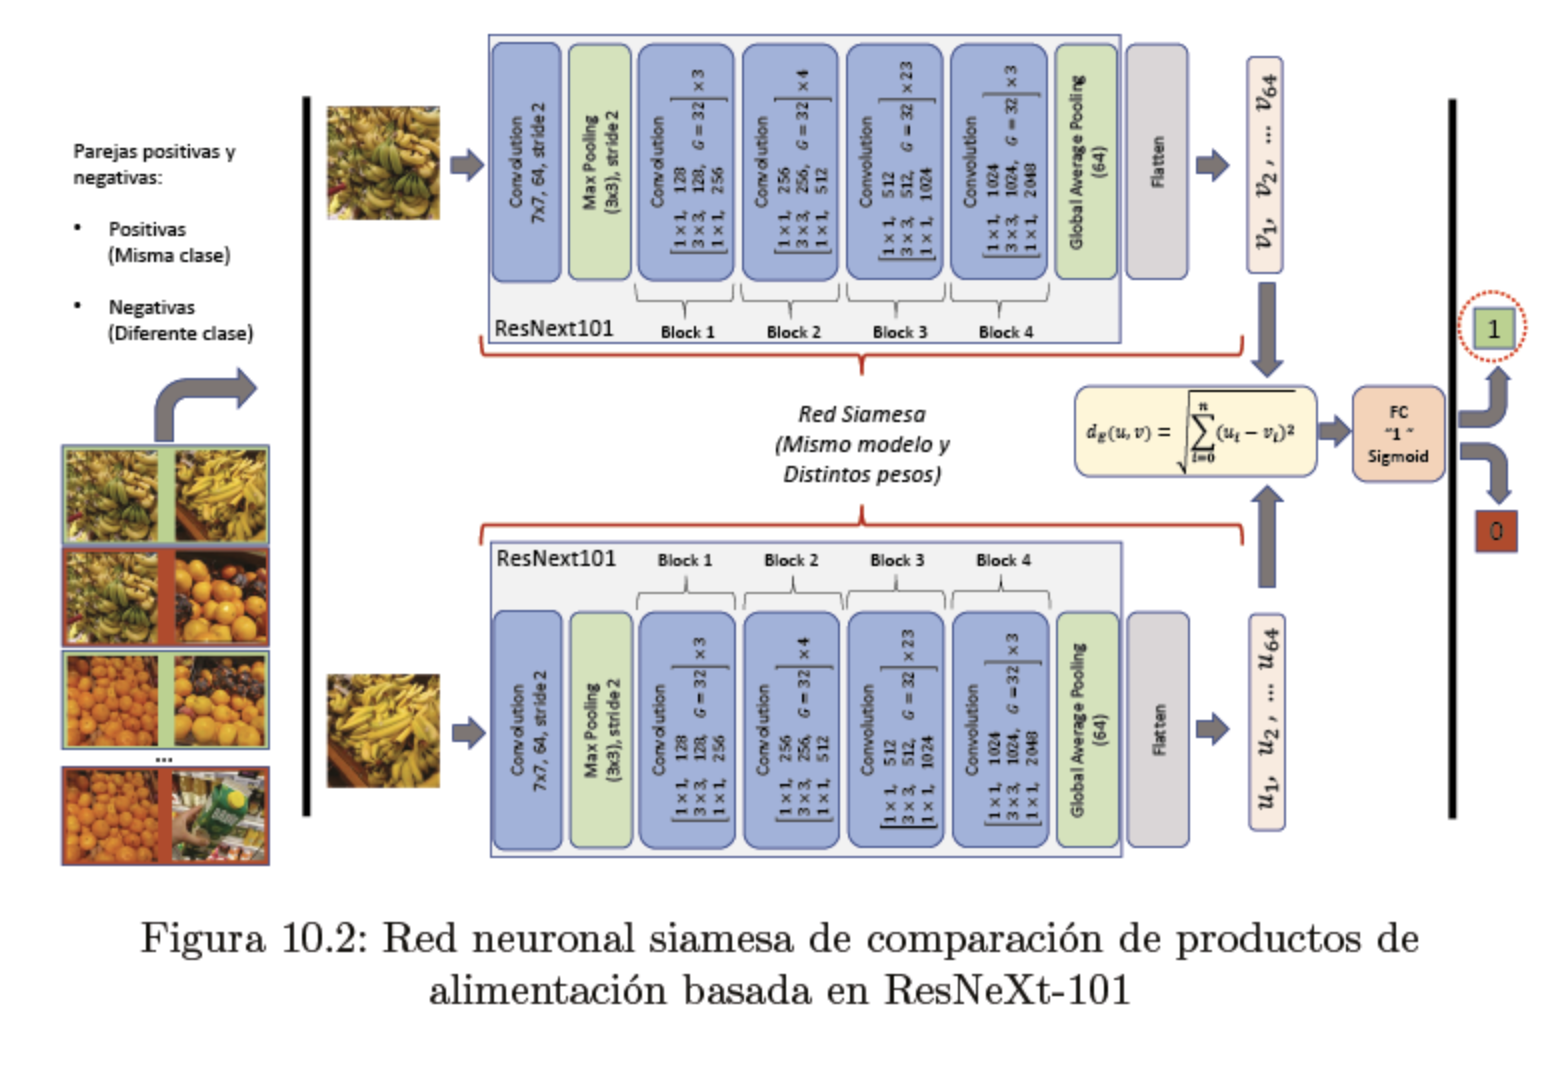

In [ ]:
# Importamos las librerías necesarias
import time
import os
import numpy as np
import random
import cv2
import matplotlib.pyplot as plt

# Importamos las librerías de Tensorflow
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dropout, BatchNormalization, Dense
#from tensorflow.keras.layers import GlobalAveragePooling2D,GlobalMaxPooling2D
#from tensorflow.keras.layers import Flatten,  ,Lambda
from tensorflow.keras.models import Model
from tensorflow.keras import layers, metrics
from tensorflow.keras.optimizers import Adam

In [ ]:
# https://paperswithcode.com/dataset/lfw
# https://archive.org/download/lfw-dataset/lfw-dataset.zip

!wget -O lfw-dataset.zip https://archive.org/download/lfw-dataset/lfw-dataset.zip
!unzip lfw-dataset.zip

--2025-05-11 21:31:40--  https://archive.org/download/lfw-dataset/lfw-dataset.zip
Resolving archive.org (archive.org)... 207.241.224.2
Connecting to archive.org (archive.org)|207.241.224.2|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://ia600708.us.archive.org/19/items/lfw-dataset/lfw-dataset.zip [following]
--2025-05-11 21:31:41--  https://ia600708.us.archive.org/19/items/lfw-dataset/lfw-dataset.zip
Resolving ia600708.us.archive.org (ia600708.us.archive.org)... 207.241.227.168
Connecting to ia600708.us.archive.org (ia600708.us.archive.org)|207.241.227.168|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 116405332 (111M) [application/zip]
Saving to: ‘lfw-dataset.zip’

lfw-dataset.zip     100%[===================>] 111.01M  51.0MB/s    in 2.2s    

2025-05-11 21:31:43 (51.0 MB/s) - ‘lfw-dataset.zip’ saved [116405332/116405332]

Archive:  lfw-dataset.zip
  inflating: peopleDevTest.csv       
  inflating: matchpairsDevTrain.c

In [ ]:
!ls

lfw_allnames.csv       matchpairsDevTrain.csv	  peopleDevTest.csv
lfw-dataset.zip        mismatchpairsDevTest.csv   peopleDevTrain.csv
lfw-deepfunneled.zip   mismatchpairsDevTrain.csv  sample_data
lfw_readme.csv	       pairs.csv
matchpairsDevTest.csv  people.csv


In [ ]:
!unzip lfw-deepfunneled.zip

Se truncaron las últimas líneas 5000 del resultado de transmisión.
   creating: lfw-deepfunneled/Amy_Smart/
  inflating: lfw-deepfunneled/Amy_Smart/Amy_Smart_0001.jpg  
   creating: __MACOSX/lfw-deepfunneled/Amy_Smart/
  inflating: __MACOSX/lfw-deepfunneled/Amy_Smart/._Amy_Smart_0001.jpg  
  inflating: __MACOSX/lfw-deepfunneled/._Amy_Smart  
   creating: lfw-deepfunneled/Peter_Arnett/
  inflating: lfw-deepfunneled/Peter_Arnett/Peter_Arnett_0002.jpg  
   creating: __MACOSX/lfw-deepfunneled/Peter_Arnett/
  inflating: __MACOSX/lfw-deepfunneled/Peter_Arnett/._Peter_Arnett_0002.jpg  
  inflating: lfw-deepfunneled/Peter_Arnett/Peter_Arnett_0003.jpg  
  inflating: __MACOSX/lfw-deepfunneled/Peter_Arnett/._Peter_Arnett_0003.jpg  
  inflating: lfw-deepfunneled/Peter_Arnett/Peter_Arnett_0001.jpg  
  inflating: __MACOSX/lfw-deepfunneled/Peter_Arnett/._Peter_Arnett_0001.jpg  
  inflating: __MACOSX/lfw-deepfunneled/._Peter_Arnett  
   creating: lfw-deepfunneled/Abdul_Rahman/
  inflating: lfw-deepfun

In [ ]:
!ls

lfw_allnames.csv      __MACOSX			 pairs.csv
lfw-dataset.zip       matchpairsDevTest.csv	 people.csv
lfw-deepfunneled      matchpairsDevTrain.csv	 peopleDevTest.csv
lfw-deepfunneled.zip  mismatchpairsDevTest.csv	 peopleDevTrain.csv
lfw_readme.csv	      mismatchpairsDevTrain.csv  sample_data


In [ ]:
# Cambiar a la ruta apropiada
RUTA_DATASET = "/content/lfw-deepfunneled"

def leer_imagen(name):
    path = os.path.join(RUTA_DATASET, name[:-9], name)
    #print(path)
    imagen = cv2.imread(path)
    # Check if the image was loaded successfully
    if imagen is None:
        print(f"Error loading image: {path}")  # Print an error message
        return None  # Or handle the error in another way
    imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    return imagen


In [ ]:
#####################################################################
# Dividimos el dataset en entrenamiento y test
#####################################################################
def dividir_dataset(path, split=0.9):
    folders = os.listdir(path)
    # Filter out files that are not directories
    folders = [folder for folder in folders if os.path.isdir(os.path.join(path, folder))]
    num_train = int(len(folders)*split)

    random.shuffle(folders)

    # Creamos un diccionario para almacenar la lista de ficheros por carpeta
    train_list, test_list = {}, {}

    # Creamos el diccionario de train
    for folder in folders[:num_train]:
        num_files = len(os.listdir(os.path.join(path, folder)))
        train_list[folder] = num_files

    # Creamos el diccionario de test
    for folder in folders[num_train:]:
        num_files = len(os.listdir(os.path.join(path, folder)))
        test_list[folder] = num_files

    return train_list, test_list

train_list, test_list = dividir_dataset(RUTA_DATASET, split=0.9)
print("Tamaño del juego de entrenamiento:", len(train_list))
print("Tamaño del juego de test:", len(test_list))


Tamaño del juego de entrenamiento: 5174
Tamaño del juego de test: 575


In [ ]:
#####################################################################
# Creamos tripletas, formadas por una imagen, una imagen de la misma
# categoría y una imagen de una categoría diferente
#####################################################################
# Capa de Atención Multi-Cabeza (Multi-Head Attention)
# Implementa la parte central del Transformer: múltiples cabezas de atención en paralelo.
# #####################################################################
class MultiHeadAttentionLayer(nn.Module):
    def __init__(self, hid_dim, n_heads, dropout, device):
        super().__init__()

        # Asegura que la dimensión total sea divisible entre el número de cabezas
        assert hid_dim % n_heads == 0

        # Dimensiones básicas
        self.hid_dim = hid_dim          # Dimensión total del embedding
        self.n_heads = n_heads          # Número de cabezas de atención
        self.head_dim = hid_dim // n_heads  # Dimensión por cabeza

        # Proyecciones lineales para query (Q), key (K) y value (V)
        self.fc_q = nn.Linear(hid_dim, hid_dim)
        self.fc_k = nn.Linear(hid_dim, hid_dim)
        self.fc_v = nn.Linear(hid_dim, hid_dim)

        # Capa final que combina todas las cabezas
        self.fc_o = nn.Linear(hid_dim, hid_dim)

        # Dropout para regularización
        self.dropout = nn.Dropout(dropout)

        # Escala para normalizar los puntajes de atención
        self.scale = torch.sqrt(torch.FloatTensor([self.head_dim])).to(device)

    def forward(self, query, key, value, mask=None):
        batch_size = query.shape[0]

        # query, key, value tienen forma: [batch size, seq len, hid dim]

        # Proyecciones lineales
        Q = self.fc_q(query)
        K = self.fc_k(key)
        V = self.fc_v(value)

        # Reorganizamos Q, K, V para separar las múltiples cabezas
        # De (batch, seq_len, hid_dim) → (batch, n_heads, seq_len, head_dim)
        Q = Q.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3)
        K = K.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3)
        V = V.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3)

        # Calculamos la "energía" o puntajes de atención: Q * K^T / sqrt(d_k)
        energy = torch.matmul(Q, K.permute(0, 1, 3, 2)) / self.scale
        # energy = [batch size, n_heads, query len, key len]

        # Aplicamos máscara si existe (por ejemplo, para ignorar padding)
        if mask is not None:
            energy = energy.masked_fill(mask == 0, -1e10)

        # Calculamos los pesos de atención (softmax sobre la dimensión key_len)
        attention = torch.softmax(energy, dim=-1)
        # attention = [batch size, n_heads, query len, key len]

        # Aplicamos la atención a los valores V
        x = torch.matmul(self.dropout(attention), V)
        # x = [batch size, n_heads, query len, head dim]

        # Reordenamos las dimensiones para recombinar todas las cabezas
        x = x.permute(0, 2, 1, 3).contiguous()
        # x = [batch size, query len, n_heads, head dim]

        # Aplanamos las cabezas → concatenamos todas (n_heads * head_dim = hid_dim)
        x = x.view(batch_size, -1, self.hid_dim)
        # x = [batch size, query len, hid dim]

        # Pasamos por la capa lineal final que mezcla la información de todas las cabezas
        x = self.fc_o(x)
        # x = [batch size, query len, hid dim]

        # Devolvemos la salida final y los pesos de atención
        return x, attention


Lista de tripletas: [('Rob_Schneider_0000.jpg', 'Rob_Schneider_0001.jpg', 'Jean_Charest_0015.jpg'), ('Ricardo_Lagos_0024.jpg', 'Ricardo_Lagos_0002.jpg', 'Francis_Ford_Coppola_0000.jpg'), ('Jeremy_Greenstock_0014.jpg', 'Jeremy_Greenstock_0007.jpg', 'Benjamin_Martinez_0000.jpg'), ('Chanda_Rubin_0003.jpg', 'Chanda_Rubin_0004.jpg', 'Adriana_Lima_0000.jpg'), ('Richard_Myers_0003.jpg', 'Richard_Myers_0011.jpg', 'Claude_Jorda_0000.jpg'), ('Kurt_Warner_0003.jpg', 'Kurt_Warner_0004.jpg', 'Andrzej_Tyszkiewicz_0000.jpg'), ('Placido_Domingo_0000.jpg', 'Placido_Domingo_0002.jpg', 'Hubert_Green_0000.jpg'), ('Yoko_Ono_0004.jpg', 'Yoko_Ono_0005.jpg', 'Donald_Fehr_0003.jpg'), ('Wen_Jiabao_0004.jpg', 'Wen_Jiabao_0000.jpg', 'Nicole_Kidman_0018.jpg'), ('Kelly_Clarkson_0000.jpg', 'Kelly_Clarkson_0002.jpg', 'Eli_Broad_0000.jpg'), ('Megawati_Sukarnoputri_0024.jpg', 'Megawati_Sukarnoputri_0007.jpg', 'Bernard_Siegel_0000.jpg'), ('Gloria_Macapagal_Arroyo_0035.jpg', 'Gloria_Macapagal_Arroyo_0034.jpg', 'Isaiah_Wa

2092
Error loading image: /content/lfw-deepfunneled/Rob_Schneider/Rob_Schneider_0000.jpg
Skipping triplet: (Rob_Schneider_0000.jpg, Rob_Schneider_0001.jpg, Jean_Charest_0015.jpg) due to image loading error.
Error loading image: /content/lfw-deepfunneled/Francis_Ford_Coppola/Francis_Ford_Coppola_0000.jpg
Skipping triplet: (Ricardo_Lagos_0024.jpg, Ricardo_Lagos_0002.jpg, Francis_Ford_Coppola_0000.jpg) due to image loading error.
Error loading image: /content/lfw-deepfunneled/Benjamin_Martinez/Benjamin_Martinez_0000.jpg
Skipping triplet: (Jeremy_Greenstock_0014.jpg, Jeremy_Greenstock_0007.jpg, Benjamin_Martinez_0000.jpg) due to image loading error.
Error loading image: /content/lfw-deepfunneled/Adriana_Lima/Adriana_Lima_0000.jpg
Skipping triplet: (Chanda_Rubin_0003.jpg, Chanda_Rubin_0004.jpg, Adriana_Lima_0000.jpg) due to image loading error.
No valid images loaded in this batch. Skipping...
Error loading image: /content/lfw-deepfunneled/Claude_Jorda/Claude_Jorda_0000.jpg
Skipping triplet

'\nfor x in generar_batch(train_triplet, batch_size=num_plots, preprocess=False):\n    a,p,n = x\n\n    for i in range(num_plots):\n        # Imagen a comparar\n        axes[i, 0].imshow(a[i])        \n        axes[i, 0].set(xlabel="Anchor (Base)")\n        axes[i, 0].axes.xaxis.set_ticklabels([])\n        axes[i, 0].axes.yaxis.set_ticklabels([])\n        # Imagen positiva        \n        axes[i, 1].imshow(p[i])\n        axes[i, 1].set(xlabel="Positiva")\n        axes[i, 1].axes.xaxis.set_ticklabels([])\n        axes[i, 1].axes.yaxis.set_ticklabels([])\n        # Imagen negativa          \n        axes[i, 2].imshow(n[i])\n        axes[i, 2].set(xlabel="Negativa")\n        axes[i, 2].axes.xaxis.set_ticklabels([])\n        axes[i, 2].axes.yaxis.set_ticklabels([])        \n        i+=1\n    break\n'

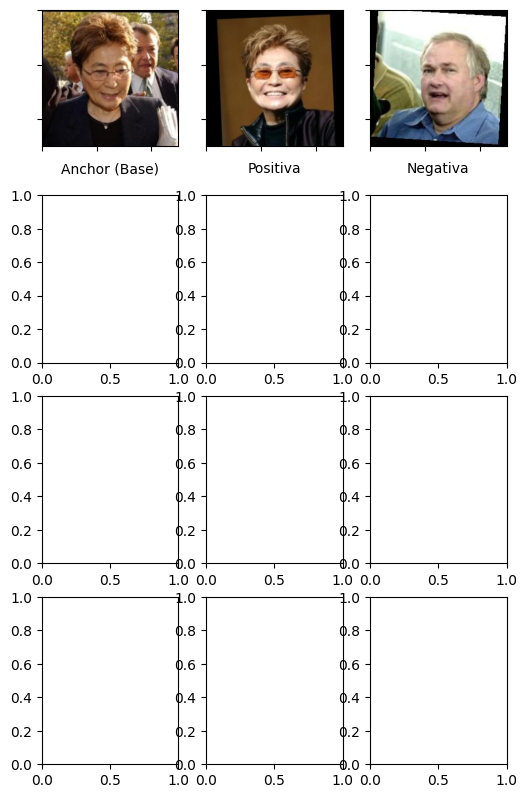

In [ ]:
###########################################################
# Creamos nuestro propio batch de tripletas. Al ser un tipo
# particular de entrenamiento donde utilizamos una
# pérdida que suma el caso positivo y el negativo, es
# necesario hacerlo de esta forma
###########################################################
def generar_batch(triplet_list, batch_size=256, preprocess=True):
    batch_steps = len(triplet_list)//batch_size
    print(batch_steps)
    for i in range(batch_steps+1):
        anchor   = []
        positiva = []
        negativa = []

        j = i*batch_size
        while j<(i+1)*batch_size and j<len(triplet_list):
            a, p, n = triplet_list[j]
            #print(a, p, n)
            # Read images and check if they are valid
            img_a = leer_imagen(a)
            img_p = leer_imagen(p)
            img_n = leer_imagen(n)

            # Only append if all images are valid
            if img_a is not None and img_p is not None and img_n is not None:
                anchor.append(img_a)
                positiva.append(img_p)
                negativa.append(img_n)
            else:
                # Skip this triplet if any image loading failed
                print(f"Skipping triplet: ({a}, {p}, {n}) due to image loading error.")

            j+=1
        # Check if any images were loaded in this batch
        if not anchor:  # If anchor is empty, the other lists will be empty too
            print("No valid images loaded in this batch. Skipping...")
            continue  # Skip to the next batch

        anchor = np.array(anchor)
        positiva = np.array(positiva)
        negativa = np.array(negativa)

        if preprocess:
            anchor = preprocess_input(anchor)
            positiva = preprocess_input(positiva)
            negativa = preprocess_input(negativa)

        yield [anchor, positiva, negativa]


#################################
# Sacamos un ejemplo de las caras
#################################
num_plots = 4
f, axes = plt.subplots(num_plots, 3, figsize=(6, 10))

# Get the first batch from the generator
batch_generator = generar_batch(train_triplet, batch_size=num_plots, preprocess=False)
a, p, n = next(batch_generator)

# Determine the actual number of images in the batch
num_images_in_batch = len(a)  # Or len(p) or len(n), they should have the same length

# Loop through the images, ensuring not to exceed the batch size
for i in range(num_images_in_batch):  # Use num_images_in_batch instead of num_plots
    # Imagen a comparar
    axes[i, 0].imshow(a[i])
    axes[i, 0].set(xlabel="Anchor (Base)")
    axes[i, 0].axes.xaxis.set_ticklabels([])
    axes[i, 0].axes.yaxis.set_ticklabels([])
    # Imagen positiva
    axes[i, 1].imshow(p[i])
    axes[i, 1].set(xlabel="Positiva")
    axes[i, 1].axes.xaxis.set_ticklabels([])
    axes[i, 1].axes.yaxis.set_ticklabels([])
    # Imagen negativa
    axes[i, 2].imshow(n[i])
    axes[i, 2].set(xlabel="Negativa")
    axes[i, 2].axes.xaxis.set_ticklabels([])
    axes[i, 2].axes.yaxis.set_ticklabels([])

'''
for x in generar_batch(train_triplet, batch_size=num_plots, preprocess=False):
    a,p,n = x

    for i in range(num_plots):
        # Imagen a comparar
        axes[i, 0].imshow(a[i])
        axes[i, 0].set(xlabel="Anchor (Base)")
        axes[i, 0].axes.xaxis.set_ticklabels([])
        axes[i, 0].axes.yaxis.set_ticklabels([])
        # Imagen positiva
        axes[i, 1].imshow(p[i])
        axes[i, 1].set(xlabel="Positiva")
        axes[i, 1].axes.xaxis.set_ticklabels([])
        axes[i, 1].axes.yaxis.set_ticklabels([])
        # Imagen negativa
        axes[i, 2].imshow(n[i])
        axes[i, 2].set(xlabel="Negativa")
        axes[i, 2].axes.xaxis.set_ticklabels([])
        axes[i, 2].axes.yaxis.set_ticklabels([])
        i+=1
    break
'''
#plt.savefig("tripletasFaceRecognition.pdf", format="pdf")
#plt.show()



In [ ]:
########################################
# Definimos las "hermanas" de la siamesa
########################################
def obtenerCodificador(input_shape = (128,128,3)):
    # Partimos de una red VGG16 pre-entrenada con ImageNet. No cogemos las 3 últimas
    # capas de clasificación. Utilizamos max pooling antes de la salida
    modelo_base = VGG16(weights='imagenet', include_top=False, pooling = 'max', input_shape = input_shape)
    # Bloqueamos el posible entrenamiento de las capas pre-entrenadas
    modelo_base.trainable = False

    # El modelo es secuencial
    modelo = Sequential()

    # Las primeras capas son las de VGG16
    modelo.add(modelo_base)

    # Añadimos dropout
    modelo.add(Dropout(0.2))

    # Cada imagen generará un vector de 128 números que normalizamos
    modelo.add(Dense(128, use_bias=False))
    modelo.add(BatchNormalization())
    return modelo


In [ ]:
###########################################
# Definimos la distancia entre los vectores
# codificados de cada imagen. Lo hacemos
# creando una capa de la red
###########################################
class Distancia(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, anchor, positiva, negativa):
        distancia_ap = tf.reduce_sum(tf.square(anchor - positiva), -1)
        distancia_an = tf.reduce_sum(tf.square(anchor - negativa), -1)
        return (distancia_ap, distancia_an)


In [ ]:
###########################################
# Definimos la red siamesa
###########################################
def obtenerModelo(input_shape = (128, 128, 3)):
    codificador = obtenerCodificador(input_shape)

    # Creamos las entradas del modelo
    anchor_input   = Input(input_shape, name="Anchor_Input")
    positiva_input = Input(input_shape, name="Positiva_Input")
    negativa_input = Input(input_shape, name="Negativa_Input")

    # Codificamos las entradas para obtener el vector asociado
    codificacion_a = codificador(anchor_input)
    codificacion_p = codificador(positiva_input)
    codificacion_n = codificador(negativa_input)

    # Calcular ‖f(A) - f(P)‖² y ‖f(A) - f(N)‖²
    distancias = Distancia()( codificacion_a, codificacion_p, codificacion_n )

    # Creamos la red siamesa
    red_siamesa = Model(
        inputs  = [anchor_input, positiva_input, negativa_input],
        outputs = distancias,
        name = "Red_Siamesa"
    )
    return red_siamesa

base_red_siamesa = obtenerModelo()
base_red_siamesa.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Red_Siamesa"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Anchor_Input        │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Positiva_Input      │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Negativa_Input      │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 128)       │ 14,780,736 │ Anchor_Input[0][… │
│ (Sequential)        │                   │            │ Positiva_Input[0… │
│                     │                   │            │ Negativa_Input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ distancia           │ [(None), (None)]  │          0 │ sequential[0][0], │
│ (Distancia)         │                   │            │ sequential[1][0], │
│                     │                   │            │ sequential[2][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,780,736 (56.38 MB)

 Trainable params: 65,792 (257.00 KB)

 Non-trainable params: 14,714,944 (56.13 MB)

In [ ]:
#######################################################
# Implementación de clase para redefinir el modelo
# de red siamesa y utilizar la pérdida triple calculada
# Referencia:
#    https://keras.io/examples/vision/siamese_network/
#######################################################
class Modelo_RedSiamesa(Model):
    # Construir la red siamesa a partir del modelo definido
    def __init__(self, siamese_network, margin=1.0):
        super(Modelo_RedSiamesa, self).__init__()

        self.margin = margin
        self.siamese_network = siamese_network
        self.loss_tracker = metrics.Mean(name="loss")

    def call(self, inputs):
        return self.siamese_network(inputs)

    # Redefinimos el paso del entrenamiento a partir de la
    # pérdida triple
    def train_step(self, data):
        # Calculamos los gradientes a partir de la pérdida triple y
        # actualizamos los pesos
        with tf.GradientTape() as tape:
            loss = self._compute_loss(data)

        gradients = tape.gradient(loss, self.siamese_network.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.siamese_network.trainable_weights))

        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    # Redefinimos el paso en evaluación. En ese caso no hay que
    # calcular gradientes y ajustar pesos
    def test_step(self, data):
        loss = self._compute_loss(data)

        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    # Cálculo de la pérdida triple
    def _compute_loss(self, data):
        ap_distance, an_distance = self.siamese_network(data)
        loss = tf.maximum(ap_distance - an_distance + self.margin, 0.0)
        return loss

    # Las métricas del modelo son la pérdida triple
    @property
    def metrics(self):
        return [self.loss_tracker]


In [ ]:
# Creamos el modelo y lo compilamos
modelo = Modelo_RedSiamesa(base_red_siamesa)
optimizer = Adam(learning_rate=0.001,epsilon=1e-01)
modelo.compile(optimizer=optimizer)

In [ ]:
#####################
# Evaluación del test
#####################
def evaluarTest(batch_size = 256):
    pos_scores, neg_scores = [], []

    for data in generar_batch(test_triplet, batch_size=batch_size):
        prediction = modelo.predict(data)
        pos_scores += list(prediction[0])
        neg_scores += list(prediction[1])

    accuracy = np.sum(np.array(pos_scores) < np.array(neg_scores)) / len(pos_scores)
    ap_mean = np.mean(pos_scores)
    an_mean = np.mean(neg_scores)
    ap_stds = np.std(pos_scores)
    an_stds = np.std(neg_scores)

    print(f"Accuracy on test = {accuracy:.5f}")
    return (accuracy, ap_mean, an_mean, ap_stds, an_stds)


In [ ]:
#############################################
# Implementamos el entrenamiento manualmente
#############################################
epochs = 10
batch_size = 256

max_acc = 0
train_loss = []
test_metrics = []

for epoch in range(1, epochs+1):
    t = time.time()

    # Entrenamos con los datos de train
    epoch_loss = []
    for data in generar_batch(train_triplet, batch_size=batch_size):
        loss = modelo.train_on_batch(data[0:3])
        epoch_loss.append(loss)
    epoch_loss = sum(epoch_loss)/len(epoch_loss)
    train_loss.append(epoch_loss)

    print(f"\nEPOCH: {epoch} \t (Epoch done in {int(time.time()-t)} sec)")
    print(f"Loss on train    = {epoch_loss:.5f}")

    # Evaluamos con los datos de test
    metric = evaluarTest(batch_size=batch_size)
    test_metrics.append(metric)
    accuracy = metric[0]

    # Guardamos los pesos cuando mejora el accuracy de test
    if accuracy>=max_acc:
        modelo.save_weights("siamese_model")
        max_acc = accuracy


Error loading image: /content/lfw-deepfunneled/Rob_Schneider/Rob_Schneider_0000.jpg
Skipping triplet: (Rob_Schneider_0000.jpg, Rob_Schneider_0001.jpg, Jean_Charest_0015.jpg) due to image loading error.
Error loading image: /content/lfw-deepfunneled/Francis_Ford_Coppola/Francis_Ford_Coppola_0000.jpg
Skipping triplet: (Ricardo_Lagos_0024.jpg, Ricardo_Lagos_0002.jpg, Francis_Ford_Coppola_0000.jpg) due to image loading error.
Error loading image: /content/lfw-deepfunneled/Benjamin_Martinez/Benjamin_Martinez_0000.jpg
Skipping triplet: (Jeremy_Greenstock_0014.jpg, Jeremy_Greenstock_0007.jpg, Benjamin_Martinez_0000.jpg) due to image loading error.
Error loading image: /content/lfw-deepfunneled/Adriana_Lima/Adriana_Lima_0000.jpg
Skipping triplet: (Chanda_Rubin_0003.jpg, Chanda_Rubin_0004.jpg, Adriana_Lima_0000.jpg) due to image loading error.
Error loading image: /content/lfw-deepfunneled/Claude_Jorda/Claude_Jorda_0000.jpg
Skipping triplet: (Richard_Myers_0003.jpg, Richard_Myers_0011.jpg, Clau

ValueError: Layer "Red_Siamesa" expects 3 input(s), but it received 5 input tensors. Inputs received: [<tf.Tensor 'data:0' shape=(31, 250, 250, 3) dtype=float32>, <tf.Tensor 'data_1:0' shape=(31, 250, 250, 3) dtype=float32>, <tf.Tensor 'data_2:0' shape=(31, 250, 250, 3) dtype=float32>, None, None]